# Winsorization and Outlier Analysis

This notebook focuses on:
1. **Winsorization** to cap extreme values in CAR data.
2. **Outlier detection** and analysis.
3. **Visualization of CAR quartiles.**

# Step 1: Load and Analyze Daily OHLC Data
This step loads daily OHLC data, calculates additional metrics like USD volume, and provides a summary of the dataset.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / "config.py").exists():
    root = root.parent
sys.path.insert(0, str(root))

# Load the daily OHLC data
from config import MAIN_DIR
daily_ohlc_file = MAIN_DIR / "daily_ohlc_capped.csv"
daily = pd.read_csv(daily_ohlc_file, parse_dates=["Date"])
daily["usd_volume"] = daily["Close"] * daily["Volume"]
daily["symbol"] = daily["Ticker"].astype(str).str.upper()
daily = daily.sort_values(["Ticker", "Date"])

print(f"Loaded {len(daily)} daily trading records")
print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Number of unique symbols: {daily['symbol'].nunique()}")

Loaded 11849649 daily trading records
Date range: 2015-01-02 to 2025-12-31
Number of unique symbols: 7069


# Step 2: Run `run_car_full.py` Script
This step runs the `run_car_full.py` script to compute cumulative abnormal returns (CARs) for all significant gaps. It calculates CARs for multiple horizons and logs extreme outliers.

In [ ]:
"""
This cell runs the `run_car_full.py` script, which computes cumulative abnormal returns (CARs)
for all significant gaps. The script:
1. Loads the significant gaps file and daily OHLC data.
2. Computes CARs for multiple horizons (e.g., same-day, +1d, +5d, etc.).
3. Saves the results to `CAR_raw_results.csv`.
4. Logs extreme outliers to `CAR_extreme_audit.csv`.

You can adjust the `price_floor` or other parameters by modifying the script or passing arguments.
"""
#            Has implemented RESUME function, so you can continue if interrupted
import subprocess

# Define the script path and arguments
script_path = project_root / "scripts" / "run_car_full.py"
args = ["python", str(script_path), "--side", "both", "--price-floor", "1.0"]

# Run the script
print("Running run_car_full.py...")
result = subprocess.run(args, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

# Step 3: Identify and Analyze Extreme Outliers in CAR Data
This step identifies extreme outliers in CAR data by calculating Z-scores for CAR columns, filtering outliers, and displaying the top 15 extreme movers.

In [2]:
from scripts.identify_outliers import identify_outliers

# Call the function to identify outliers
identify_outliers()

Loading data from CAR_raw_results.csv...
Calculating Z-scores to find outliers...
----------------------------------------
Total events analyzed: 56,916
Extreme Outliers found: 1,000
----------------------------------------
      Ticker        Date Direction  Horizon  Entry_Price  CAR_That_day  \
49757     TC  2020-10-22        up  plus_30      25.1800   7084.273233   
49756     TC  2020-10-22        up   plus_5      25.3604   7033.168247   
49755     TC  2020-10-22        up   plus_1      25.4500   7008.055010   
20783   DRUG  2024-08-26        up   plus_1       1.1400     19.298246   
9598      TC  2021-12-06      down   plus_5      25.4100  -3193.978749   
9597      TC  2021-12-06      down   plus_1      25.4150  -3193.330710   
9599      TC  2021-12-06      down  plus_30      25.4900  -3183.640643   
20785   DRUG  2024-08-26        up  plus_30       1.3900     -2.158273   
20784   DRUG  2024-08-26        up   plus_5       1.4650     -7.167235   
11022   XWEL  2017-07-26      down  

# Step 4: Process CAR Quartiles
This step processes CAR quartiles by Winsorizing CAR data, merging it with earnings data, and calculating quartiles for analysis.

In [3]:
from scripts.process_car_quartiles import process_car_quartiles

# Call the function to process CAR quartiles
process_car_quartiles()

1. Loading raw CARs and Earnings...
 -> Winsorizing CAR data to neutralize extreme split-glitches...
2. Merging datasets on Ticker and Date...
 -> Merged successfully. Total overlapping events: 1584

3. Processing Quartiles for GAP DOWN...
 -> Saved: CAR_quartiles_results_down.csv

3. Processing Quartiles for GAP UP...
 -> Saved: CAR_quartiles_results_up.csv

DONE! Your Quartiles are now clean, capped, and ready to chart.


# Step 5: Generate Quartile Charts for Gap UP and Gap DOWN
This step generates visualizations for CAR quartiles for both upward and downward gaps using the `make_quartile_charts` function.

### Compute CAR for Shorts on Gap Down
`compute_car_for_event()` calculates the standard return (how the stock price moved compared to the market benchmark). If the gap was down, the script multiplies the return by -1 (-v):

- If the stock continues to crash after the entry, the normal return is negative, but multiplying it by -1 flips it to a positive profit.
- If the stock bounces and goes up after your entry, the normal return is positive, but multiplying it by -1 flips it to a negative loss.

=== Generating Gap UP Quartile Charts ===
Loading data from CAR_quartiles_results_up.csv...
Creating charts for GAP UP...


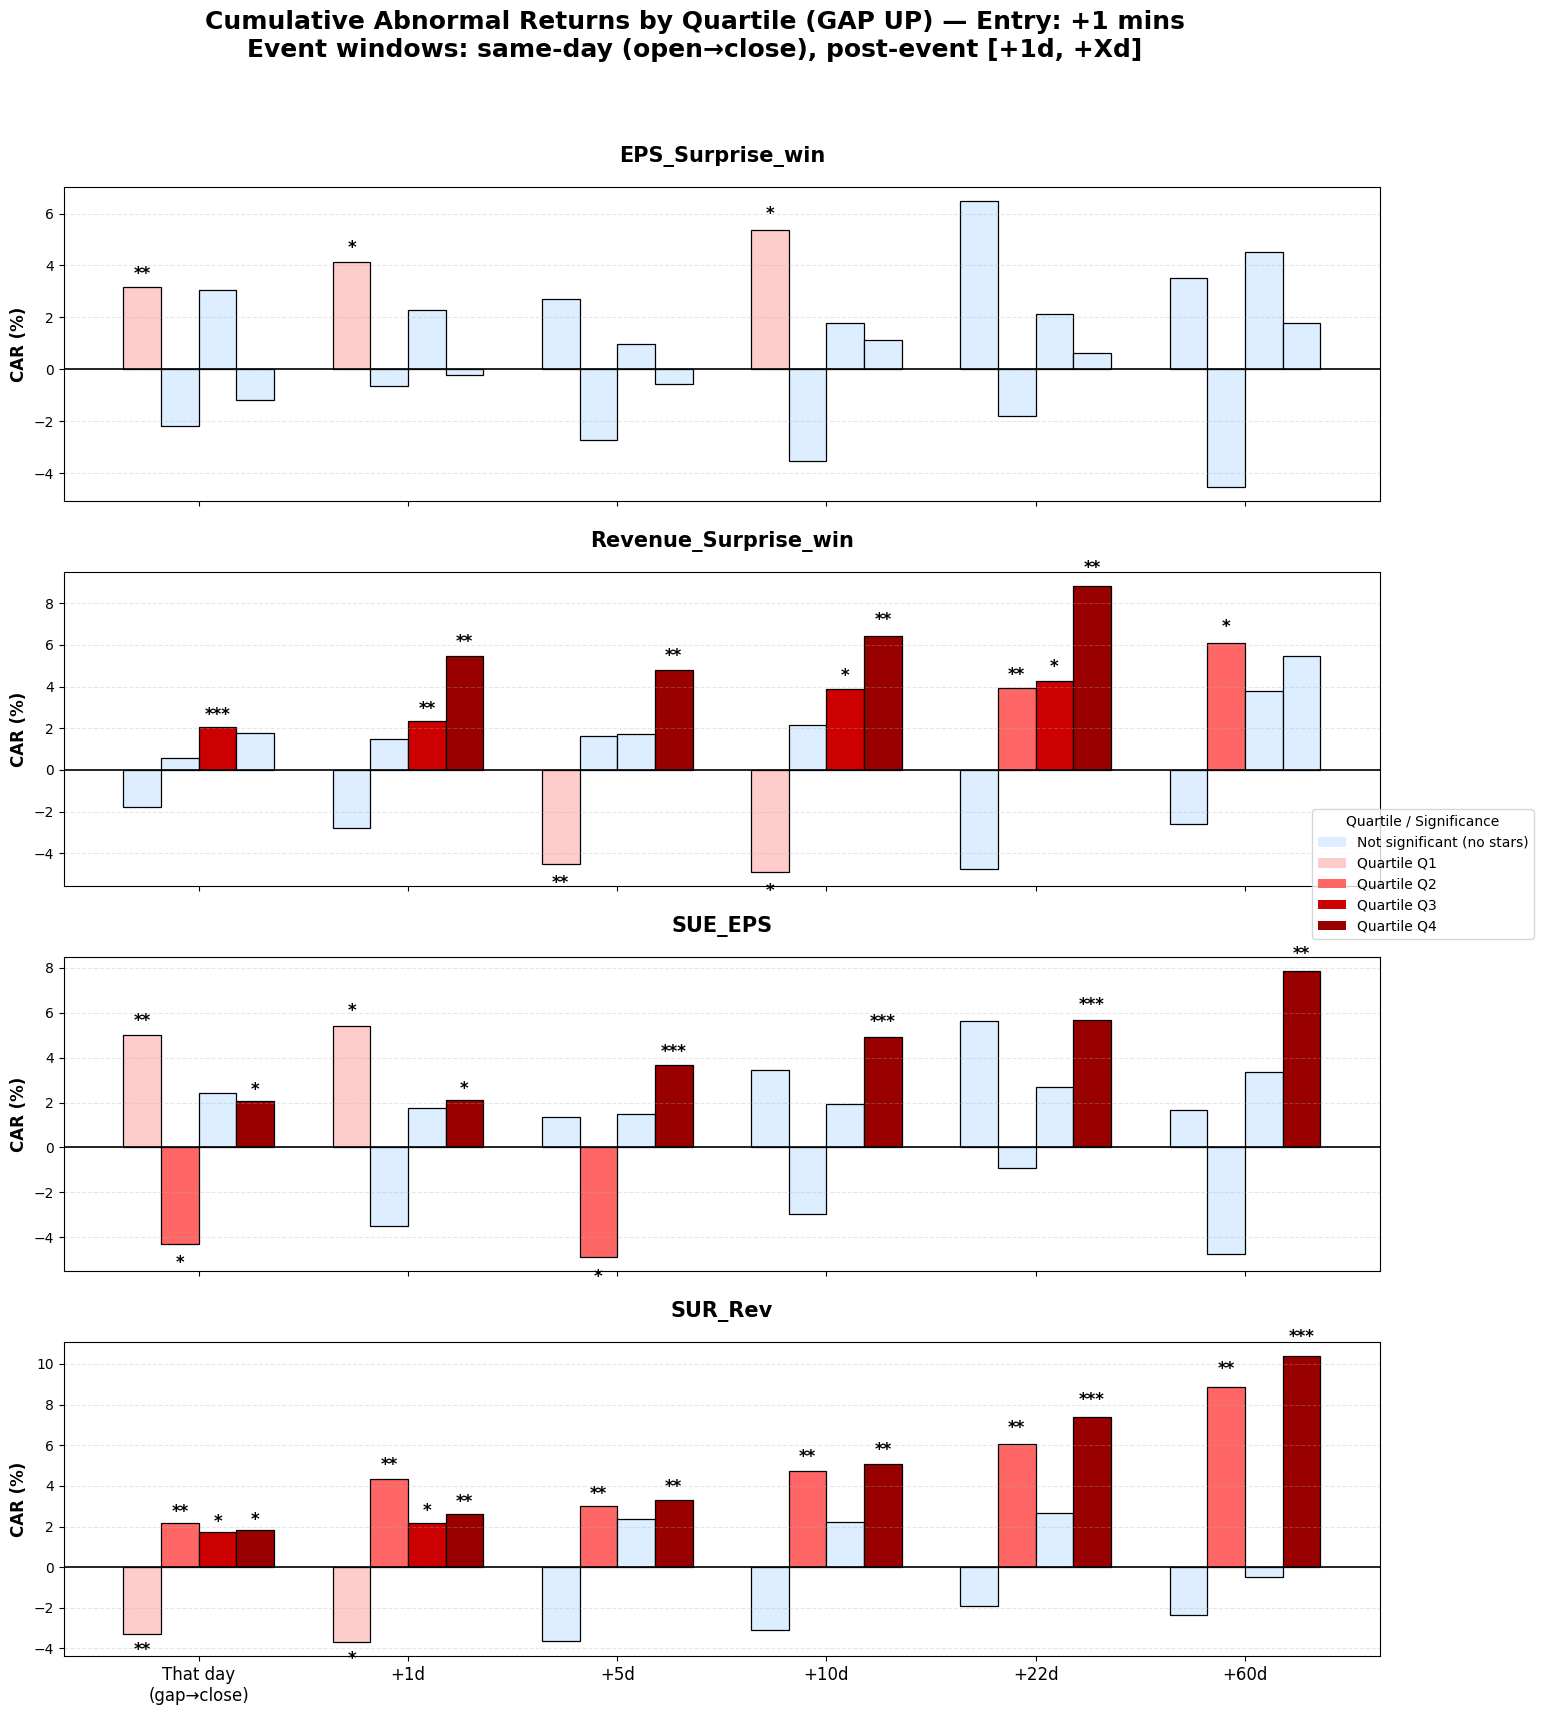

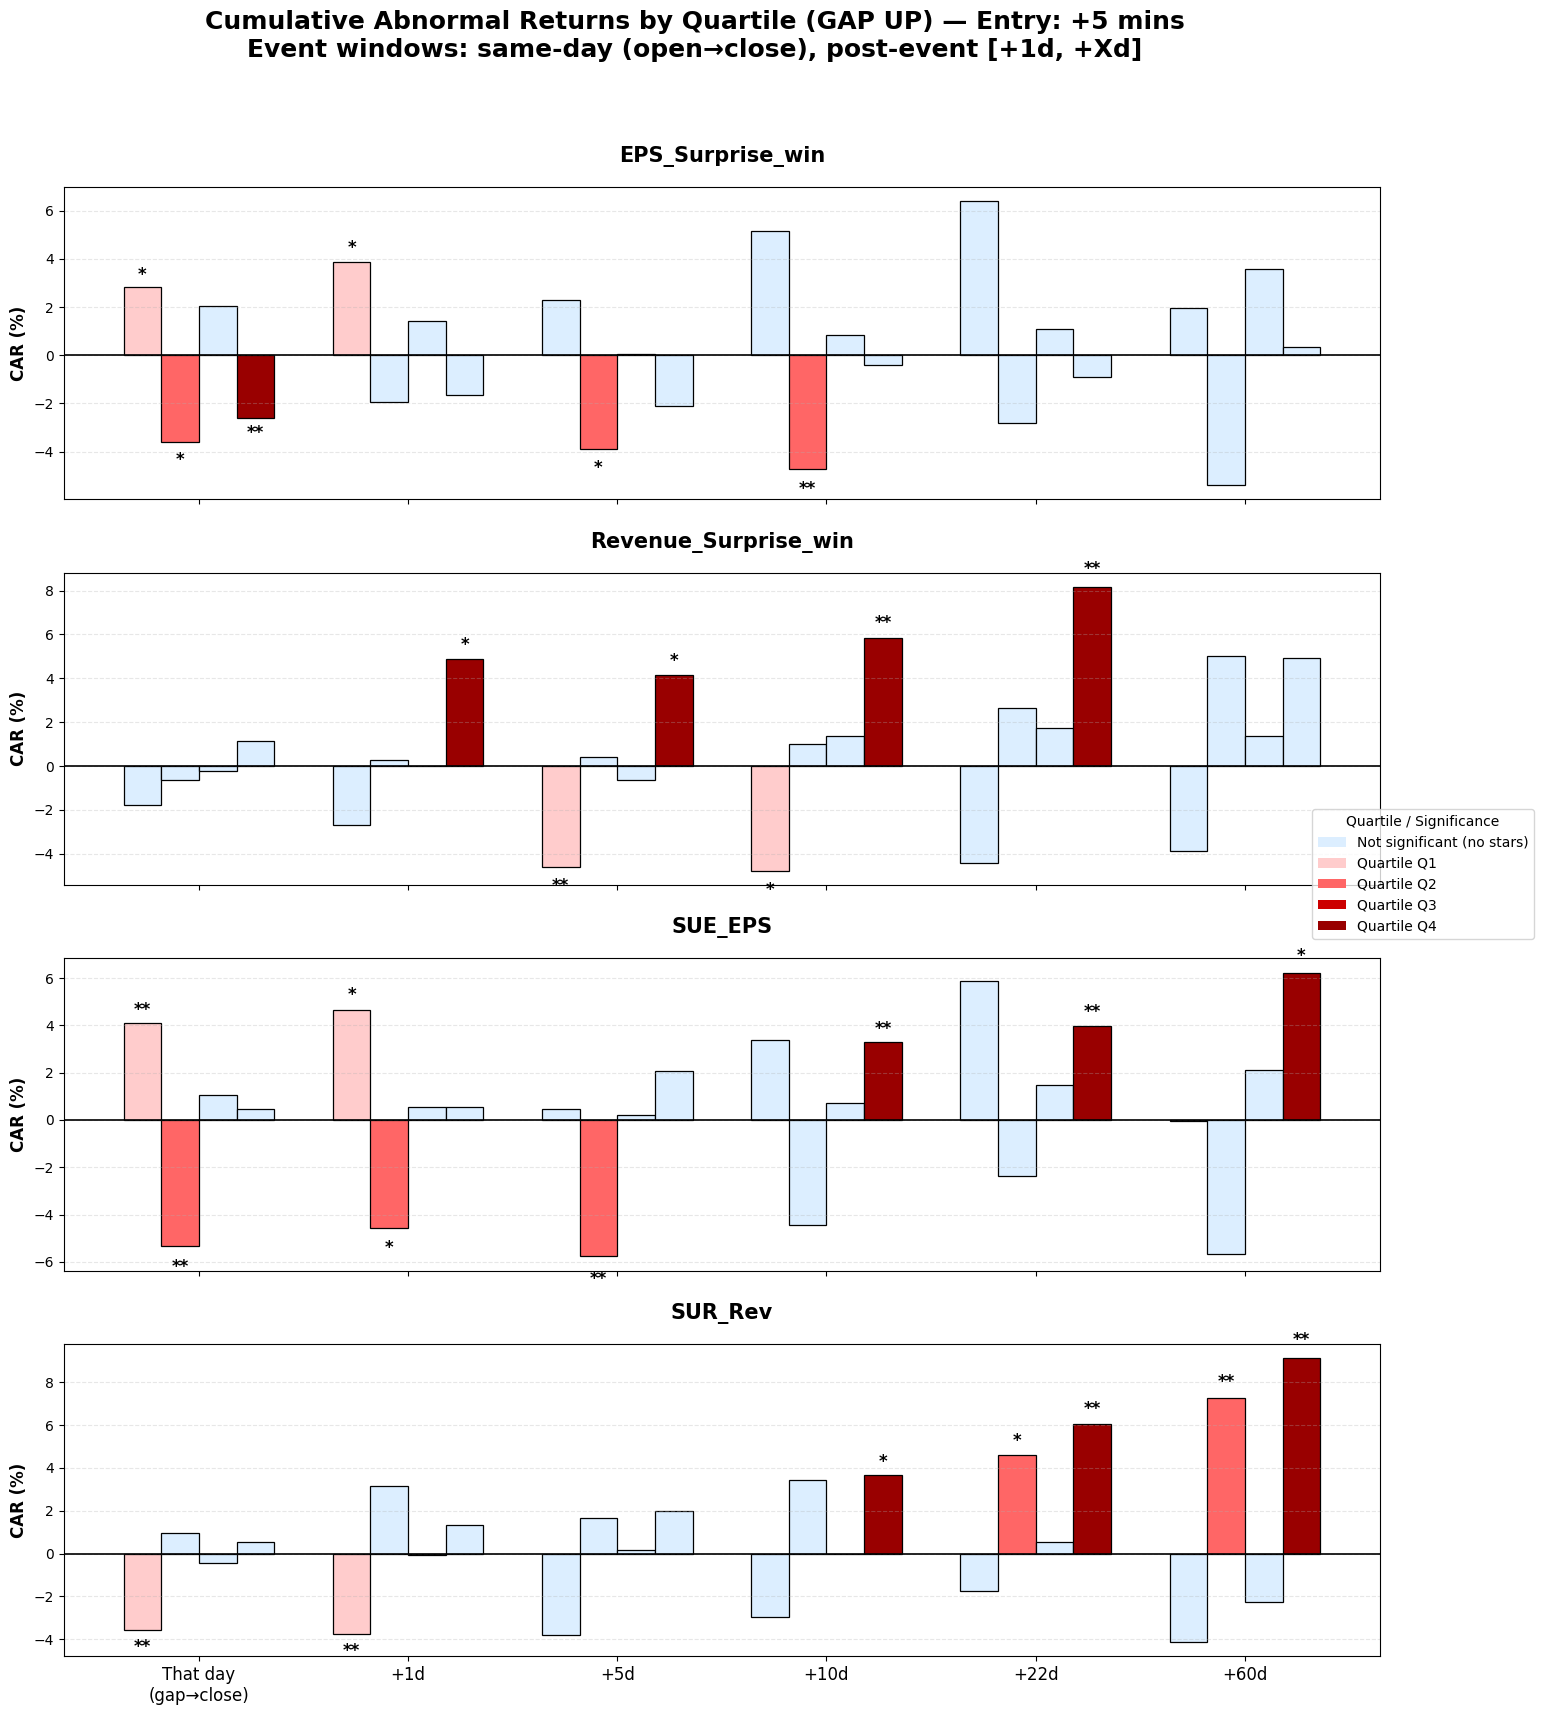

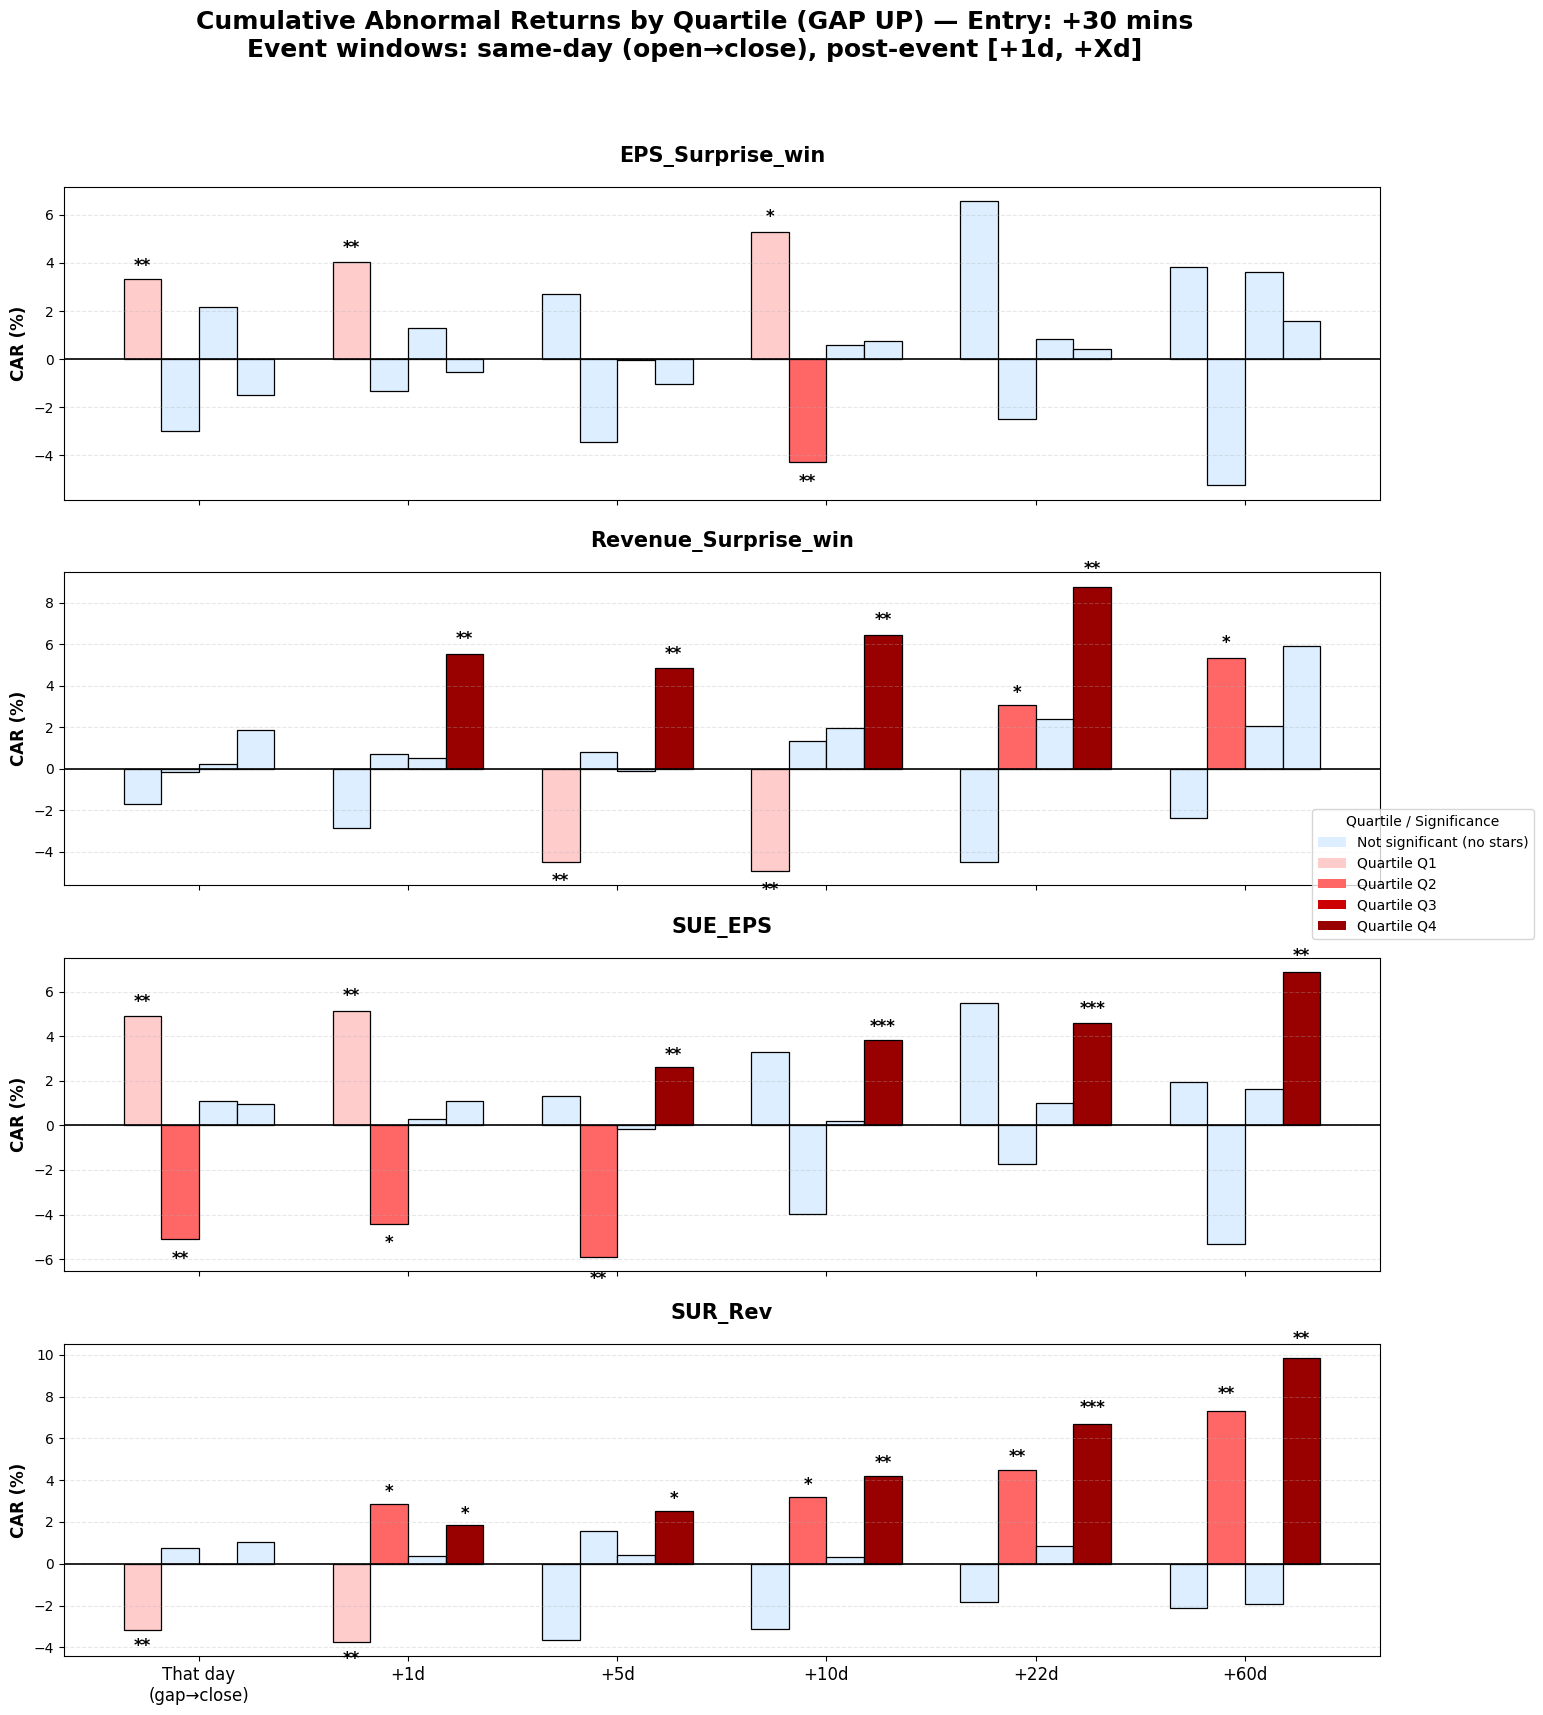


=== Generating Gap DOWN Quartile Charts ===
Loading data from CAR_quartiles_results_down.csv...
Creating charts for GAP DOWN...


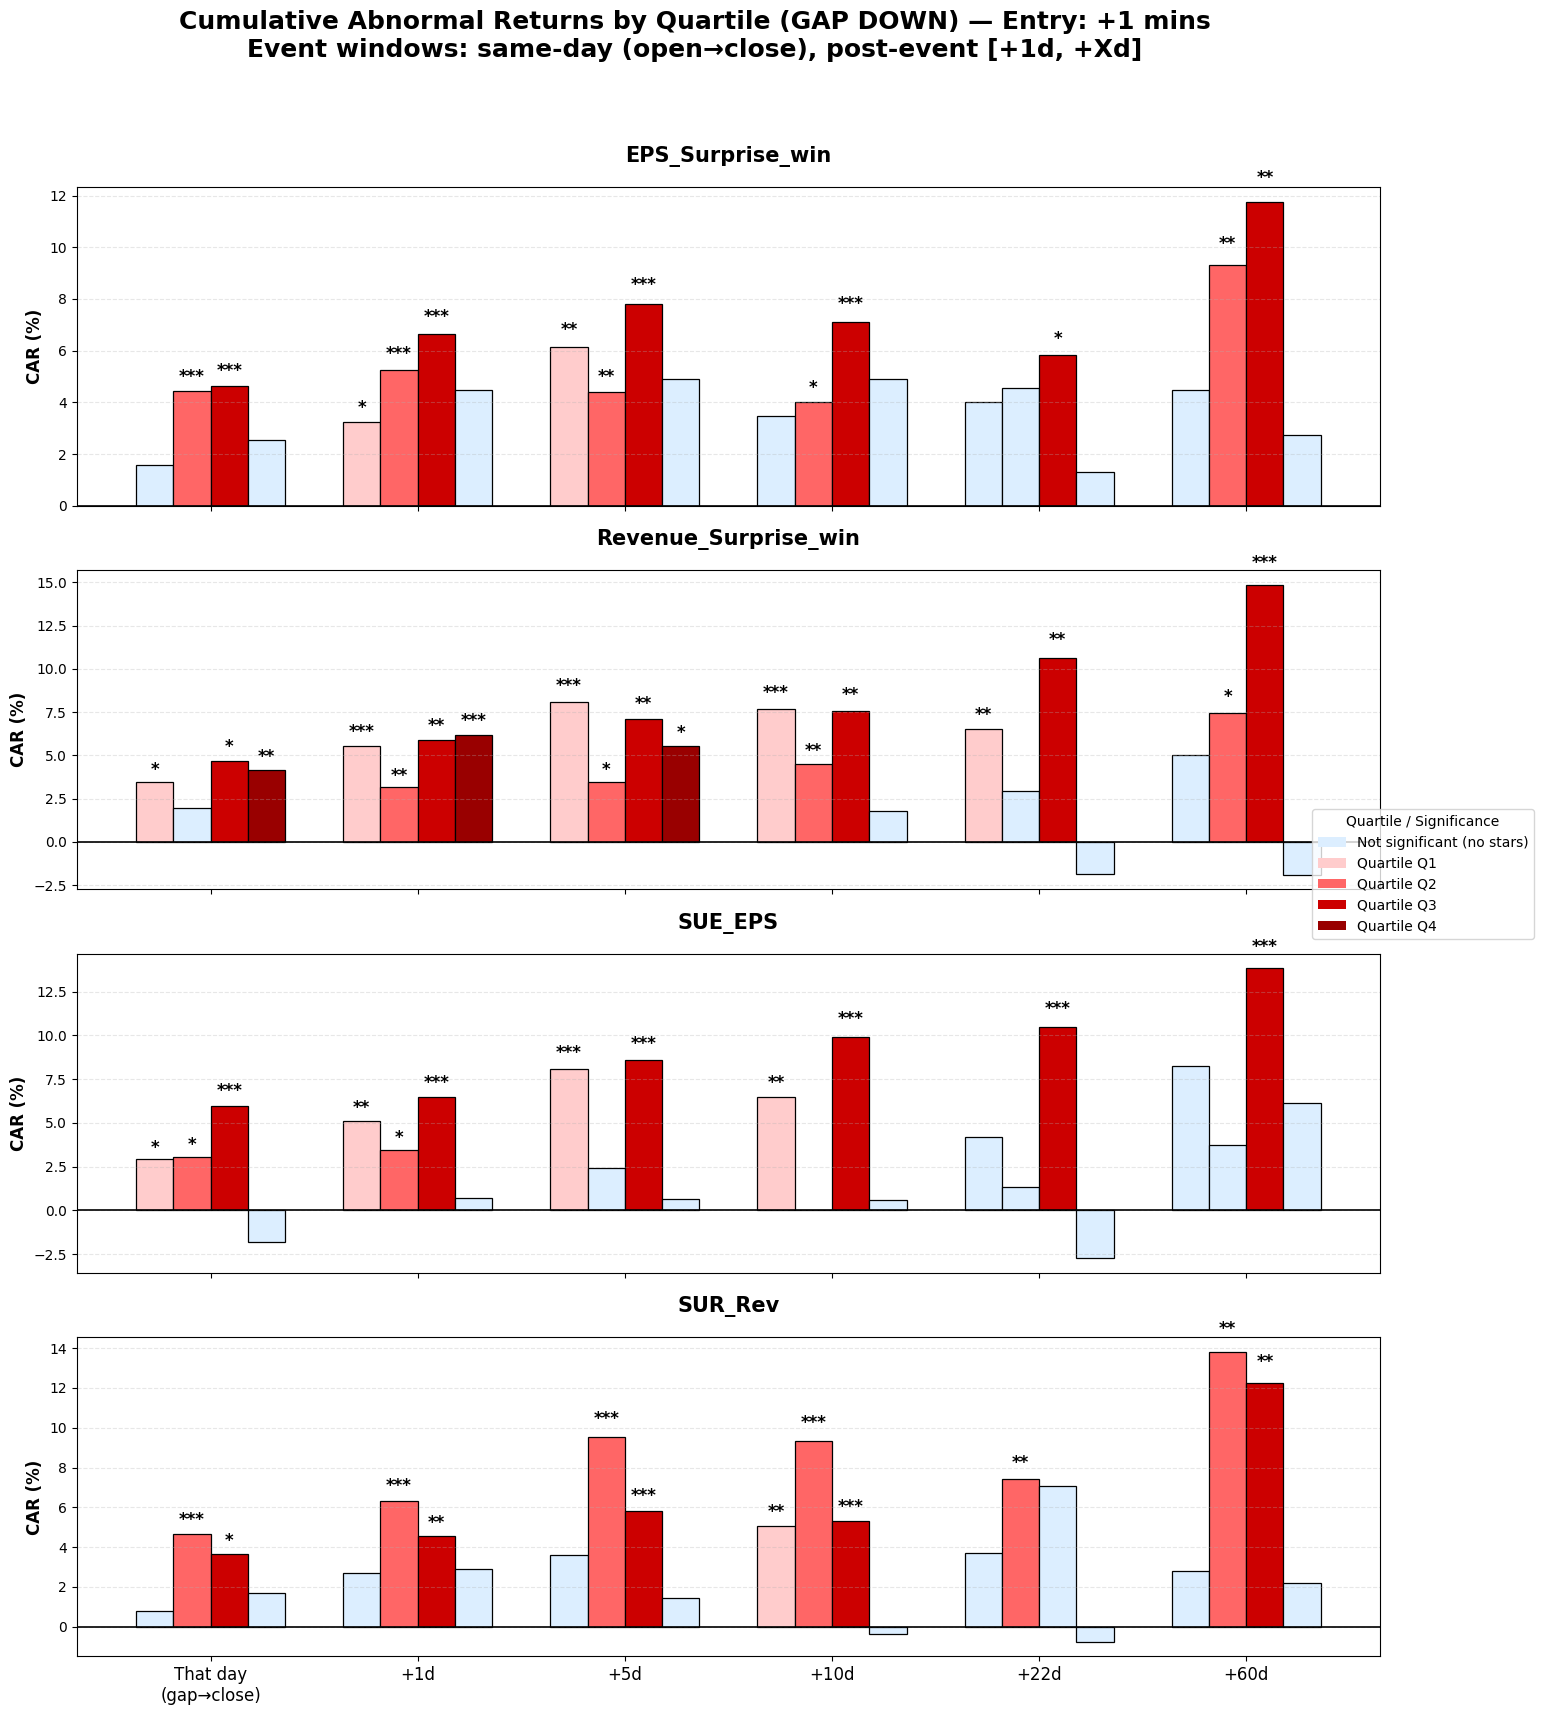

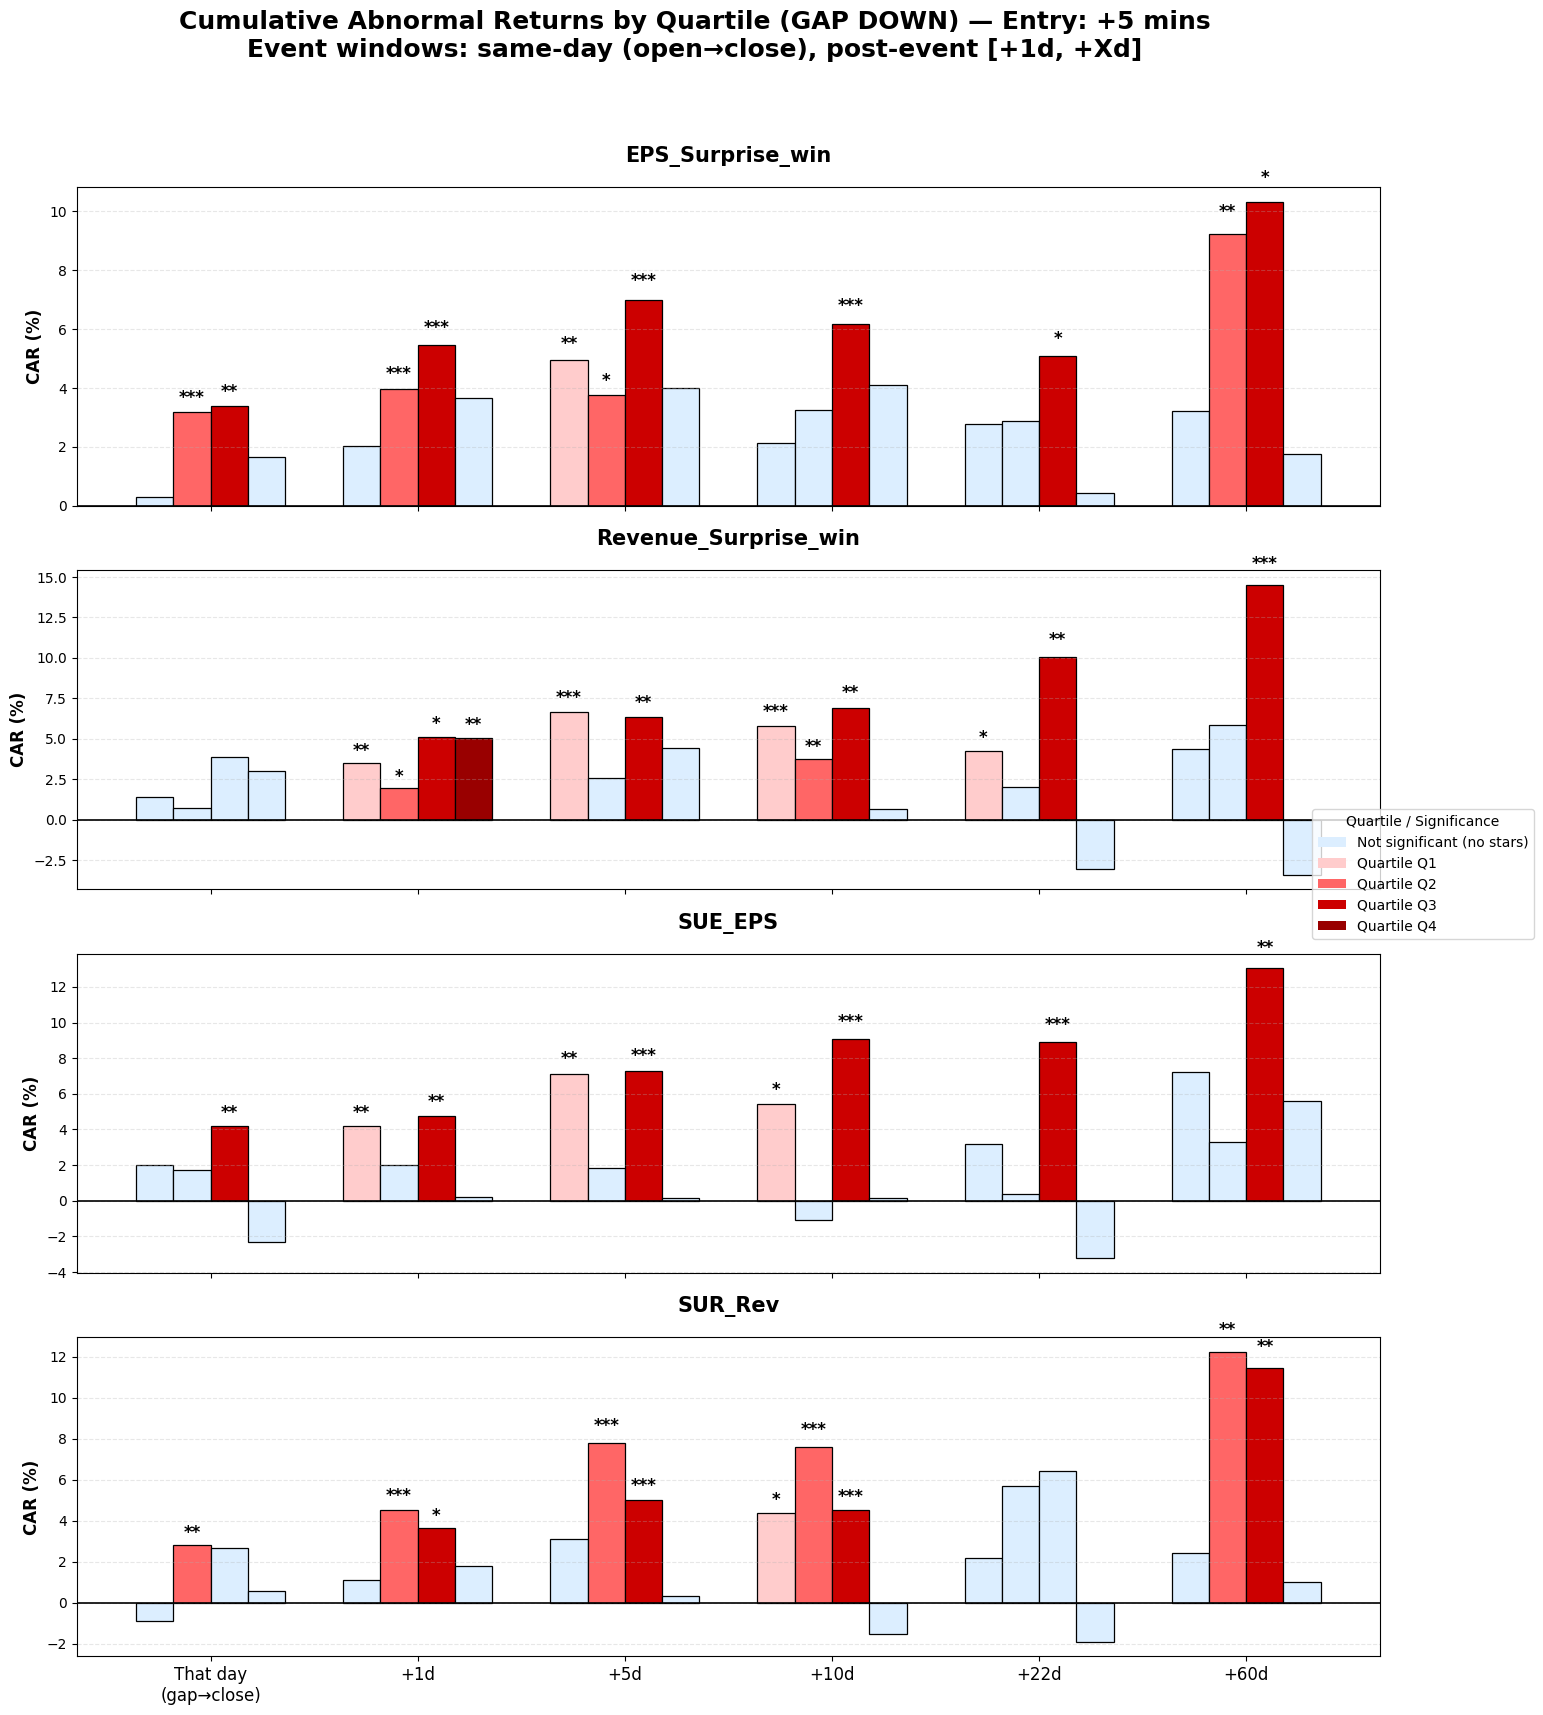

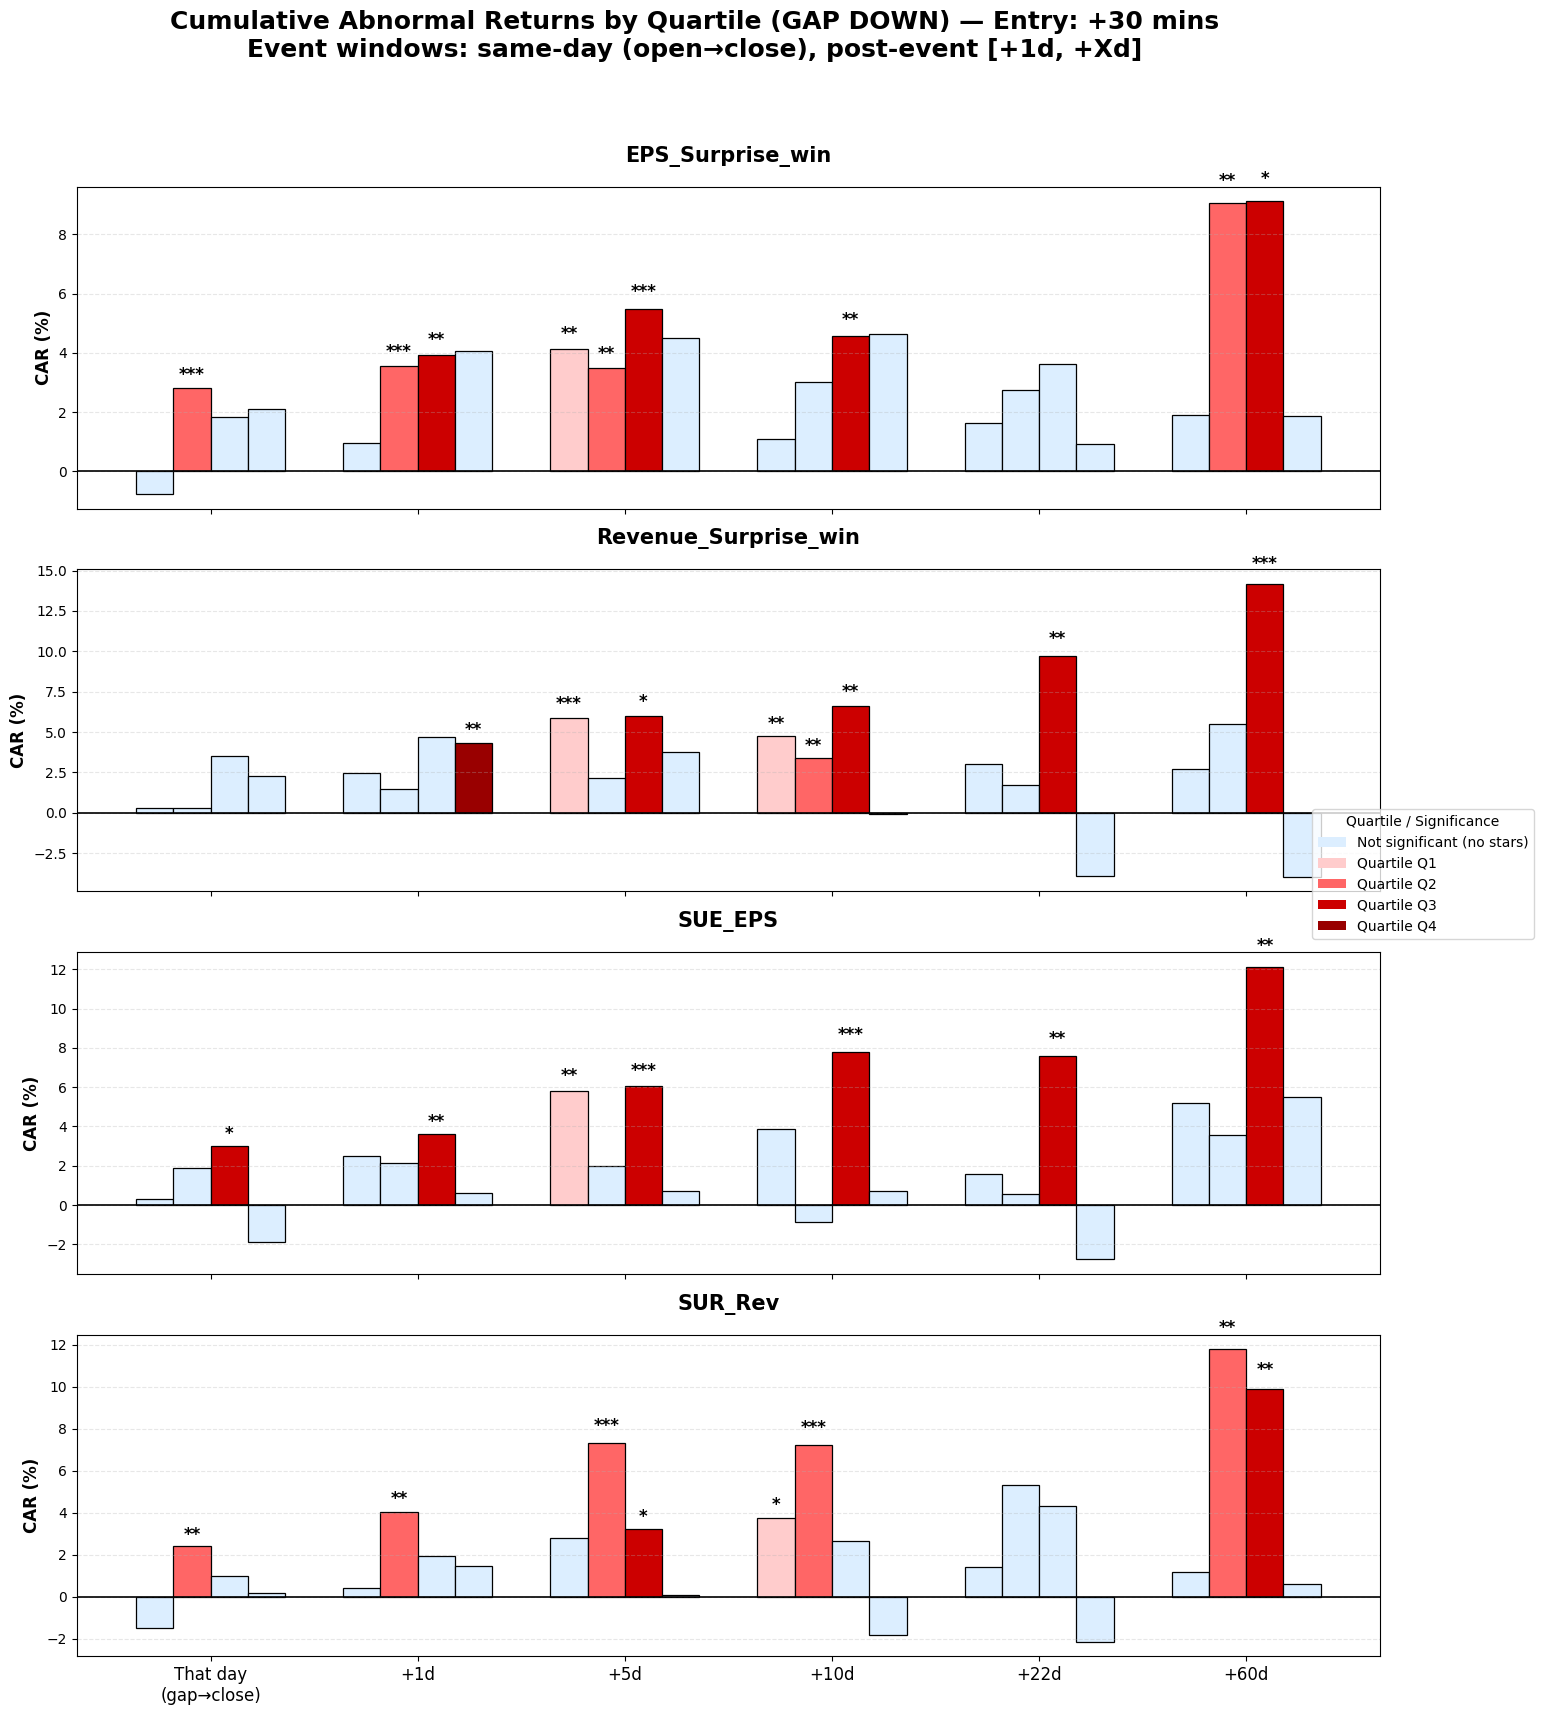

WindowsPath('C:/Users/j/python/Shocks_analysis_project/main_dataframe/charts_quartiles_redblue')

In [4]:
from config import MAIN_DIR
from scripts.plot_quartile_car import make_quartile_charts 

# 1. Generate Gap UP Quartile Charts
print("=== Generating Gap UP Quartile Charts ===")
make_quartile_charts(
    direction='up',      # Automatically looks for CAR_summary_run_table_up.csv
    main_dir=MAIN_DIR, 
    show=True,         
    save_files=False,  
    verbose=True
)

# 2. Generate Gap DOWN Quartile Charts
print("\n=== Generating Gap DOWN Quartile Charts ===")
make_quartile_charts(
    direction='down',    # Automatically looks for CAR_summary_run_table_down.csv
    main_dir=MAIN_DIR, 
    show=True,
    save_files=False, 
    verbose=True
)

# News Classification and CAR Analysis

In this section, we will:
1. Use the `groq_news_categorizer.py` script to classify financial news into predefined categories.
2. Merge the classified news categories with CAR (Cumulative Abnormal Returns) data.
3. Analyze and plot CAR results grouped by news categories.

In [ ]:
# Step 1: Classify News Using groq_news_categorizer.py
import subprocess

# Run the groq_news_categorizer.py script
script_path = MAIN_DIR / "groq_news_categorizer.py"
subprocess.run(["python", script_path], check=True)

print("News classification completed. Results saved to output files.")

In [3]:
import sys
from pathlib import Path

# Force Jupyter to look in your main project folder
ROOT_DIR = str(Path.cwd().resolve())
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

# Force reload the script so it sees the new code
%load_ext autoreload
%autoreload 2

from scripts.process_car_news import process_car_raw

print("Starting the CAR News processing...")
process_car_raw()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Starting the CAR News processing...
1. Loading datasets...
2. Applying strict hierarchy to resolve multiple news articles...
 -> Condensed 19696 articles into 3403 unique gap days with news.
3. Merging CAR returns with top news category...
4. Splitting and Saving results...
 Saved Gap DOWN results (11178 rows) to: CAR_news_results_down.csv
 Saved Gap UP results (45738 rows) to: CAR_news_results_up.csv


In [ ]:
import sys
from pathlib import Path

# Ensure Jupyter finds the scripts folder
ROOT_DIR = str(Path.cwd().resolve())
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

# Reload the script to capture the latest changes
%load_ext autoreload
%autoreload 2

from scripts.plot_category_car import plot_news_categories
from config import MAIN_DIR

print("Generating News Category Charts...")
plot_news_categories(
    main_dir=MAIN_DIR, 
    show=True,         # Show them in the notebook output
    save_files=False,   # Save them to the charts folder
    verbose=True
)
print("All charts generated!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Generating News Category Charts...

Loading CAR_news_results_up.csv...
 -> Saved Chart: CAR_Category_UP_plus_1.png
 -> Saved Chart: CAR_Category_UP_plus_5.png
 -> Saved Chart: CAR_Category_UP_plus_30.png

Loading CAR_news_results_down.csv...
 -> Saved Chart: CAR_Category_DOWN_plus_1.png
 -> Saved Chart: CAR_Category_DOWN_plus_5.png
 -> Saved Chart: CAR_Category_DOWN_plus_30.png
All charts generated!
